In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import useful_rdkit_utils as uru
from rdkit import DataStructs
from tqdm.auto import tqdm
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

/home/rohankhopkar/micromamba/envs/smolmolfinal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1775092269.961624   15062 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775092270.129730   15062 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775092271.490848   15062 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results 

In [2]:
tqdm.pandas()

In [3]:
sns.set_style("whitegrid")
sns.set_context("notebook")

In [6]:
train_df         = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TRAIN.csv") # 4140 molecules that passed the single concentration test?
test_df          = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TEST_BLINDED.csv") # 513 (63 + analog) final filtered molecules with high pEC50 AND counter assay success?
train_counter_df = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_counter-assay_TRAIN.csv") # Molecules that passed the counter assay test from the original train set?
train_single_df  = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_single_concentration_TRAIN.csv") # All of the molecules used in the single concentration test, regardless of if there was PXR reaction.

In [7]:
# Select the relevant columns
keep_cols = [
    "Molecule Name", "SMILES", "pEC50",
    "pEC50_std.error (-log10(molarity))",
    "pEC50_ci.lower (-log10(molarity))",
    "pEC50_ci.upper (-log10(molarity))",
    "Emax_estimate (log2FC vs. baseline)",
    "Emax.vs.pos.ctrl_estimate (dimensionless)",
    "Split",
]
model_df = train_df[keep_cols].copy()

# Use shorter column names for convenience
model_df = model_df.rename(columns={
    "pEC50_std.error (-log10(molarity))": "pEC50_std_error",
    "pEC50_ci.lower (-log10(molarity))":  "pEC50_ci_lower",
    "pEC50_ci.upper (-log10(molarity))":  "pEC50_ci_upper",
    "Emax_estimate (log2FC vs. baseline)":         "Emax",
    "Emax.vs.pos.ctrl_estimate (dimensionless)":   "Emax_vs_ctrl",
})
model_df.head()

,Molecule Name,SMILES,pEC50,pEC50_std_error,pEC50_ci_lower,pEC50_ci_upper,Emax,Emax_vs_ctrl,Split
0,OADMET-0006089,CC1C2CCCCC2CN1C(=O)C1=CC(F)=CC2=C1CNCC2,5.27,0.0620,5.13,5.38,1.67,0.539,Train
1,OADMET-0006088,CN(C(=O)C1=CC=CC=C1SCC(=O)N1CCC2=CC=CC=C21)C1C...,5.08,0.0870,4.89,5.22,1.70,0.491,Train
2,OADMET-0006087,O=C(C1CCCC1)N1CC(S(=O)(=O)NC2CC2C2=C(F)C=CC=C2...,5.12,0.1660,4.79,5.39,1.88,0.663,Train
3,OADMET-0006086,CC1CN(C(=O)C2=CC=CC(C3=C(F)C=CC=C3F)=C2)CCN1C1...,5.23,0.1120,4.99,5.42,2.20,0.889,Train
4,OADMET-0006085,CC1(C2=NOC(C3=NN(CC4=CC=C(F)C=C4)C(=O)CC3)=N2)...,5.28,0.0466,5.18,5.37,1.82,0.623,Train


### FEATENG

In [8]:
rdkit_desc = uru.RDKitDescriptors()

In [9]:
# Work with the subset that has a valid pEC50 measurement
train_pec50 = model_df.dropna(subset=["pEC50"]).copy()
print(f"Compounds with valid pEC50: {len(train_pec50)}")

train_pec50["descriptors"] = [rdkit_desc.calc_smiles(x) for x in tqdm(train_pec50.SMILES)]

Compounds with valid pEC50: 4140


100%|██████████| 4140/4140 [00:17<00:00, 239.85it/s]


In [10]:
from rdkit.Chem import AllChem
from rdkit import Chem

def get_morgan_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

train_pec50["morgan_fp"] = train_pec50["SMILES"].apply(get_morgan_fp)

# Concatenate with existing descriptors
X = np.hstack([
    np.stack(train_pec50.descriptors),
    np.stack(train_pec50.morgan_fp)
])

[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerator
[20:13:02] DEPRECATION WARNING: please use MorganGenerat

### TRAINING

In [11]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import numpy as np

def scaffold_split(df, test_size=0.25, smiles_col="SMILES", seed=42):
    """Split a dataframe by Bemis-Murcko scaffold."""
    # Get scaffold for each molecule
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        scaffolds[scaffold].append(idx)

    # Shuffle scaffold groups
    scaffold_groups = list(scaffolds.values())
    rng = np.random.default_rng(seed)
    rng.shuffle(scaffold_groups)

    # Fill test set up to test_size
    n_test_target = int(len(df) * test_size)
    train_idx, test_idx = [], []
    for group in scaffold_groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(group)
        else:
            train_idx.extend(group)

    return df.loc[train_idx], df.loc[test_idx]

In [12]:
result_list = []
for i in tqdm(range(7)):
    train, test = scaffold_split(train_pec50, smiles_col="SMILES", seed=i)

    X_train = np.hstack([np.stack(train.descriptors), np.stack(train.morgan_fp)])
    X_test = np.hstack([np.stack(test.descriptors), np.stack(test.morgan_fp)])

    lgbm = LGBMRegressor(verbose=-1)
    # weights = 1 / train["pEC50_std_error"].clip(lower=0.01)

    # lgbm.fit(X_train, train["pEC50"], sample_weight=weights)
    lgbm.fit(np.stack(X_train), train["pEC50"])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        pred = lgbm.predict(X_test)

    r2 = r2_score(test["pEC50"], pred)
    result_list.append([len(train), len(test), r2])

100%|██████████| 7/7 [00:23<00:00,  3.32s/it]


### EVAL

In [13]:
result_df = pd.DataFrame(result_list, columns=["Num_Train", "Num_Test", "R2"])
result_df

,Num_Train,Num_Test,R2
0,3105,1035,0.545709
1,3105,1035,0.639032
2,3105,1035,0.620858
3,3104,1036,0.583516
4,3105,1035,0.550977
5,3105,1035,0.686293
6,3105,1035,0.544161


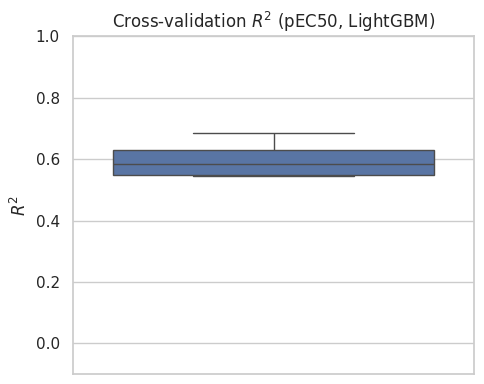

In [14]:
sns.set(rc={"figure.figsize": (5, 4)})
sns.set(style="whitegrid")
ax = sns.boxplot(y="R2", data=result_df)
ax.set_ylim(-0.1, 1)
ax.set_ylabel("$R^2$")
ax.set_title("Cross-validation $R^2$ (pEC50, LightGBM)")
plt.tight_layout()

In [18]:
train_pec50.descriptors

0       [2.9056088584221658, 2.423295406665708, -2.283...
1       [3.4092734498964155, 2.2679570502859403, -2.24...
2       [3.0485900981502936, 2.479027863099911, -2.395...
3       [3.278526894458471, 2.2952615651777055, -2.400...
4       [3.068851434429667, 2.3838463335835387, -2.342...
                              ...                        
4135    [2.594995204095219, 2.1559019361628957, -2.173...
4136    [3.1598995091041577, 2.1243472937957666, -2.05...
4137    [3.106257922652601, 2.167560248369186, -2.2624...
4138    [3.1936539963511423, 2.259252541816174, -2.242...
4139    [3.1429997779383587, 2.2954058329543554, -2.31...
Name: descriptors, Length: 4140, dtype: object

<Axes: >

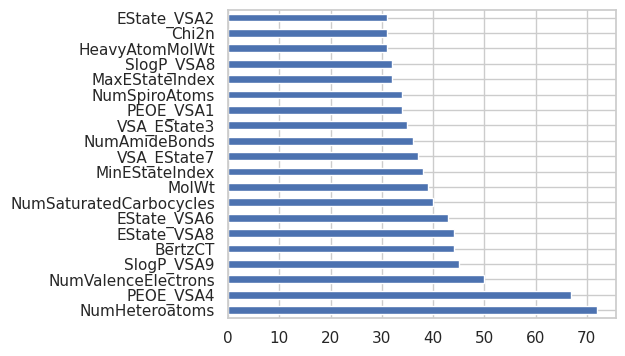

In [19]:
from rdkit.Chem import Descriptors

descriptor_names = [x[0] for x in Descriptors._descList]

feat_names = (
    descriptor_names +
    [f"morgan_{i}" for i in range(2048)]
)

importances = pd.Series(lgbm.feature_importances_, index=feat_names)
importances.nlargest(20).plot(kind="barh")

### Compare Analogues

Fitting scaler on training set...
Computing RDKit FPs for analogue search...


[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerator
[10:27:27] DEPRECATION WARNING: please use MorganGenerat

Finding analogue pairs (this may take a moment)...
Found 14 analogue pairs
Precomputing normalized features...


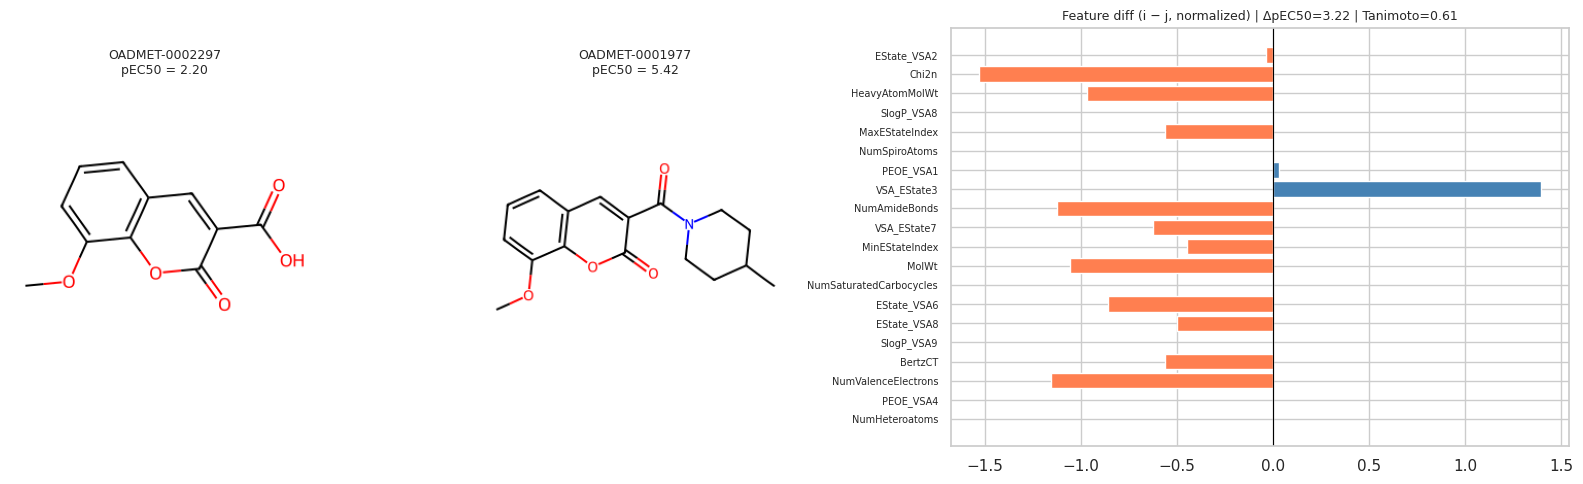

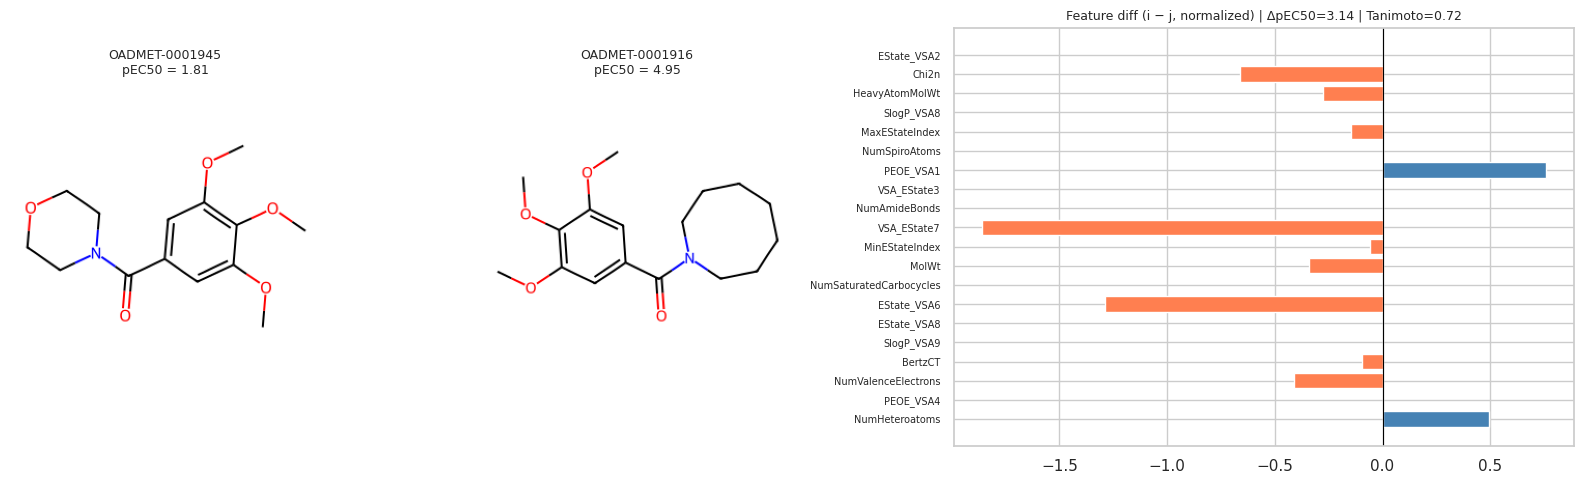

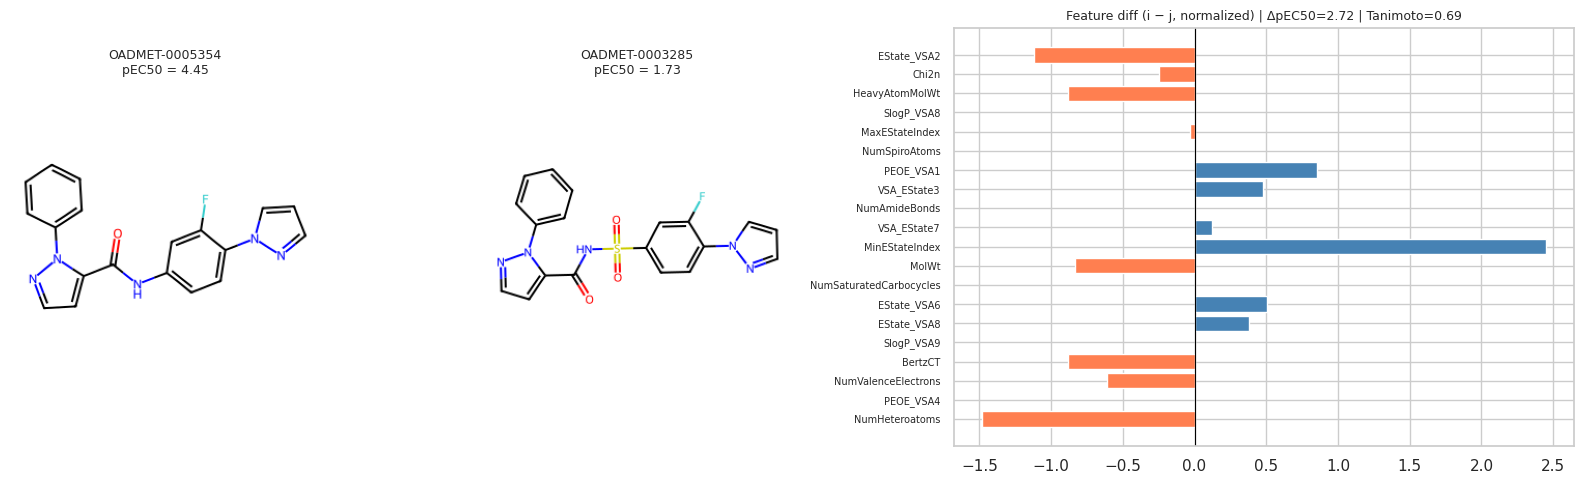

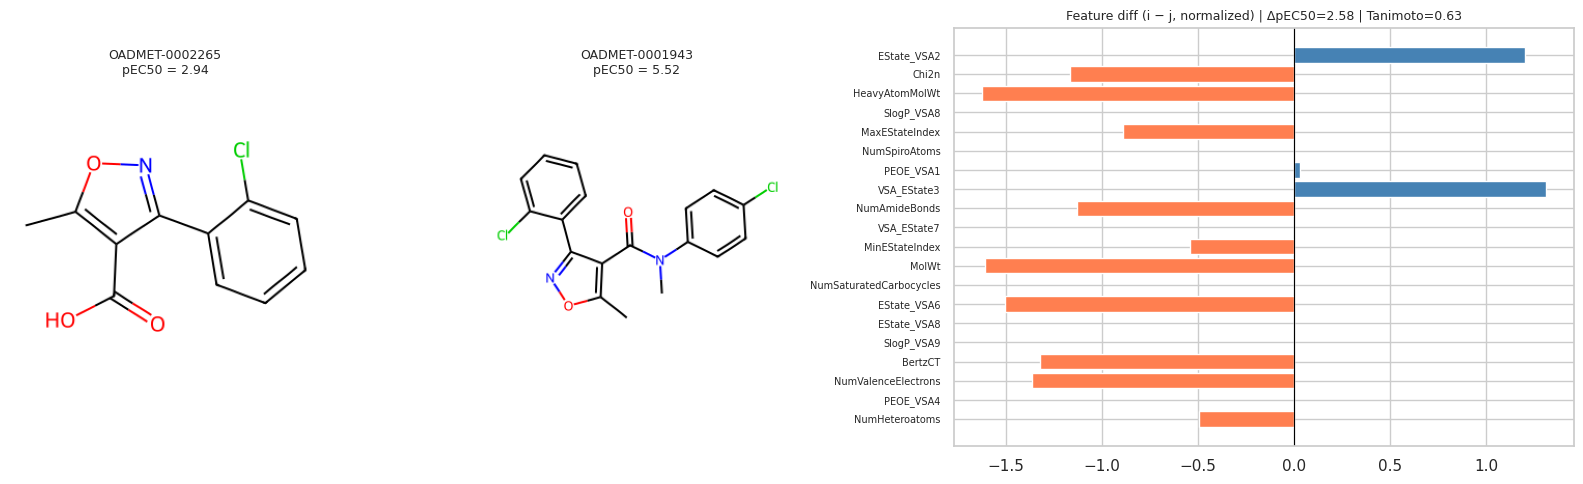

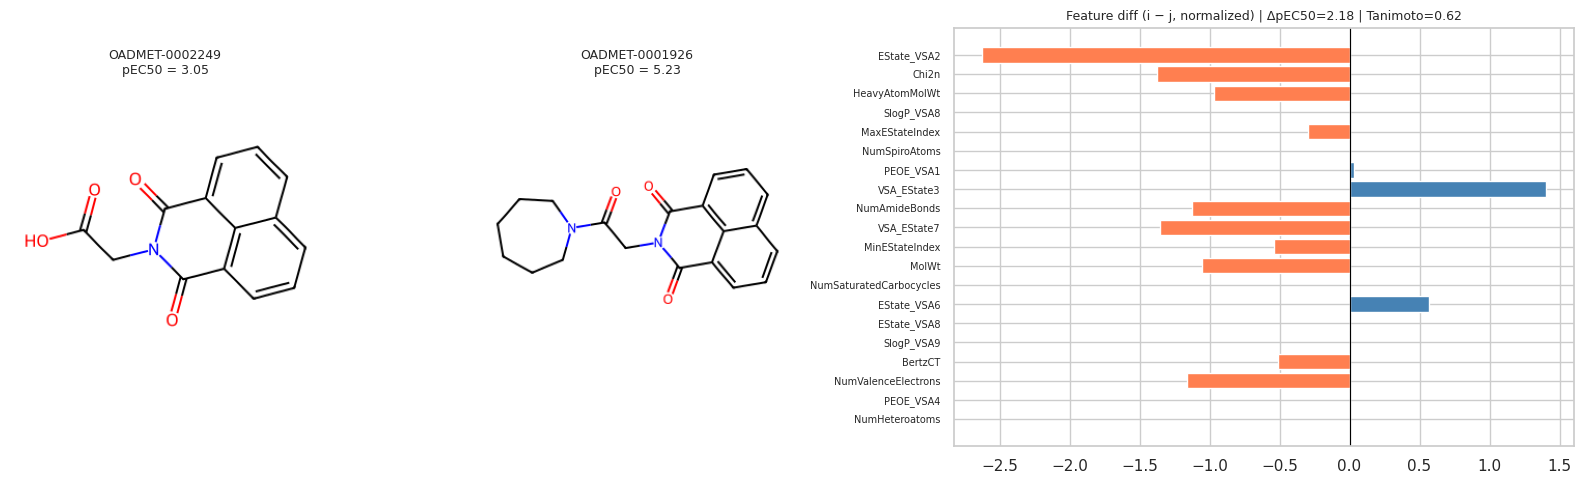

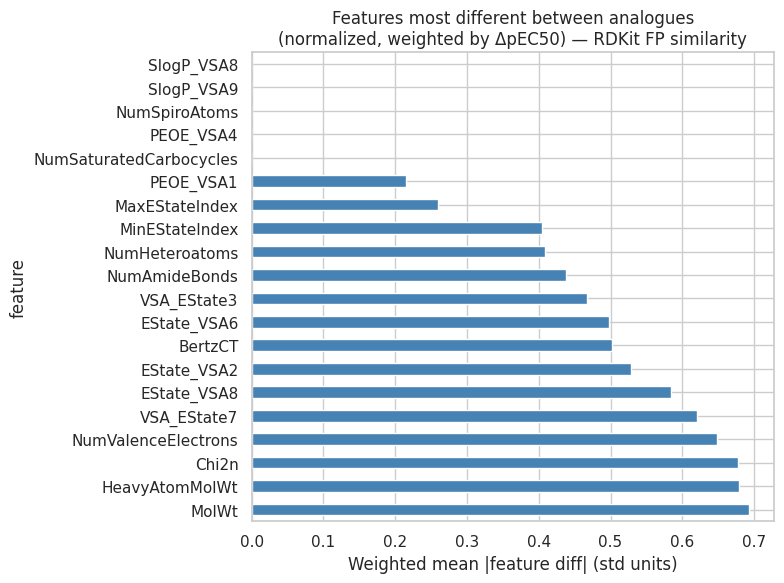

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, DataStructs
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem, RDKFingerprint
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

TOP_FEATURES = [
    "NumHeteroatoms", "PEOE_VSA4", "NumValenceElectrons", "BertzCT",
    "SlogP_VSA9", "EState_VSA8", "EState_VSA6", "NumSaturatedCarbocycles",
    "MolWt", "MinEStateIndex", "VSA_EState7", "NumAmideBonds",
    "VSA_EState3", "PEOE_VSA1", "NumSpiroAtoms", "MaxEStateIndex",
    "SlogP_VSA8", "HeavyAtomMolWt", "Chi2n", "EState_VSA2"
]

def compute_top_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {f: np.nan for f in TOP_FEATURES}
    desc_dict = dict(Descriptors.CalcMolDescriptors(mol))
    return {f: desc_dict.get(f, np.nan) for f in TOP_FEATURES}

def get_morgan_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

# ── 1. Fit scaler on full training set ───────────────────────────────────────
print("Fitting scaler on training set...")
train_feat_matrix = pd.DataFrame(
    [compute_top_features(s) for s in train_pec50["SMILES"]],
    index=train_pec50["SMILES"]
).fillna(0)

scaler = StandardScaler()
scaler.fit(train_feat_matrix[TOP_FEATURES])

# ── 2. Find analogue pairs ────────────────────────────────────────────────────
print("Computing RDKit FPs for analogue search...")
train_pec50["_fp"] = train_pec50["SMILES"].apply(get_morgan_fp)

def find_analogue_pairs(df, similarity_threshold=0.5, pec50_delta_threshold=1.5):
    fps = list(df["_fp"])
    smiles = list(df["SMILES"])
    pec50 = list(df["pEC50"])
    names = list(df["Molecule Name"]) if "Molecule Name" in df.columns else list(df.index)

    pairs = []
    for i in range(len(fps)):
        if fps[i] is None:
            continue
        for j in range(i + 1, len(fps)):
            if fps[j] is None:
                continue
            sim = TanimotoSimilarity(fps[i], fps[j])
            delta = abs(pec50[i] - pec50[j])
            if sim >= similarity_threshold and delta >= pec50_delta_threshold:
                pairs.append({
                    "idx_i": i, "idx_j": j,
                    "name_i": names[i], "name_j": names[j],
                    "smiles_i": smiles[i], "smiles_j": smiles[j],
                    "pec50_i": pec50[i], "pec50_j": pec50[j],
                    "delta_pec50": delta,
                    "tanimoto": sim,
                })
    return pd.DataFrame(pairs).sort_values("delta_pec50", ascending=False)

print("Finding analogue pairs (this may take a moment)...")
pairs_df = find_analogue_pairs(train_pec50, similarity_threshold=0.6, pec50_delta_threshold=1.5)
print(f"Found {len(pairs_df)} analogue pairs")

# ── 3. Precompute normalized features for all unique SMILES in pairs ──────────
print("Precomputing normalized features...")
unique_smiles = list(set(pairs_df["smiles_i"].tolist() + pairs_df["smiles_j"].tolist()))
raw_feat_matrix = pd.DataFrame(
    [compute_top_features(s) for s in unique_smiles],
    index=unique_smiles
).fillna(0)

scaled_values = scaler.transform(raw_feat_matrix[TOP_FEATURES])
scaled_feat_matrix = pd.DataFrame(scaled_values, index=unique_smiles, columns=TOP_FEATURES)

# ── 4. Plot pairs using normalized features ───────────────────────────────────
def plot_analogue_pair(row, ax_mol_i, ax_mol_j, ax_feat):
    mol_i = Chem.MolFromSmiles(row["smiles_i"])
    mol_j = Chem.MolFromSmiles(row["smiles_j"])
    img_i = Draw.MolToImage(mol_i, size=(300, 300))
    img_j = Draw.MolToImage(mol_j, size=(300, 300))
    ax_mol_i.imshow(img_i)
    ax_mol_i.set_title(f"{row['name_i']}\npEC50 = {row['pec50_i']:.2f}", fontsize=9)
    ax_mol_i.axis("off")
    ax_mol_j.imshow(img_j)
    ax_mol_j.set_title(f"{row['name_j']}\npEC50 = {row['pec50_j']:.2f}", fontsize=9)
    ax_mol_j.axis("off")

    fi = scaled_feat_matrix.loc[row["smiles_i"]]
    fj = scaled_feat_matrix.loc[row["smiles_j"]]
    feat_names, deltas = [], []
    for f in TOP_FEATURES:
        feat_names.append(f)
        deltas.append(fi[f] - fj[f])

    colors = ["steelblue" if d > 0 else "coral" for d in deltas]
    ax_feat.barh(feat_names, deltas, color=colors)
    ax_feat.axvline(0, color="black", linewidth=0.8)
    ax_feat.set_title(
        f"Feature diff (i − j, normalized) | ΔpEC50={row['delta_pec50']:.2f} | Tanimoto={row['tanimoto']:.2f}",
        fontsize=9
    )
    ax_feat.tick_params(axis="y", labelsize=7)

def plot_top_pairs(pairs_df, n=5):
    for _, row in pairs_df.head(n).iterrows():
        fig = plt.figure(figsize=(16, 5))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 2])
        ax_i = fig.add_subplot(gs[0])
        ax_j = fig.add_subplot(gs[1])
        ax_f = fig.add_subplot(gs[2])
        plot_analogue_pair(row, ax_i, ax_j, ax_f)
        plt.tight_layout()
        plt.show()

plot_top_pairs(pairs_df, n=5)

# ── 5. Aggregate normalized feature diffs across top 100 pairs ───────────────
records = []
for _, row in pairs_df.head(100).iterrows():
    fi = scaled_feat_matrix.loc[row["smiles_i"]]
    fj = scaled_feat_matrix.loc[row["smiles_j"]]
    for f in TOP_FEATURES:
        records.append({
            "feature": f,
            "abs_diff": abs(fi[f] - fj[f]),
            "delta_pec50": row["delta_pec50"]
        })

feat_diff_df = pd.DataFrame(records)
summary = (
    feat_diff_df.groupby("feature")
    .apply(lambda g: np.average(g["abs_diff"], weights=g["delta_pec50"]))
    .sort_values(ascending=False)
    .rename("weighted_mean_abs_diff_normalized")
)

summary.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Features most different between analogues\n(normalized, weighted by ΔpEC50) — RDKit FP similarity")
plt.xlabel("Weighted mean |feature diff| (std units)")
plt.tight_layout()
plt.show()

Now do the same with RDKit Descriptors instead of Morgan Fingerprints

Fitting scaler on training set...
Computing RDKit FPs for analogue search...
Finding analogue pairs (this may take a moment)...
Found 324 analogue pairs
Precomputing normalized features...


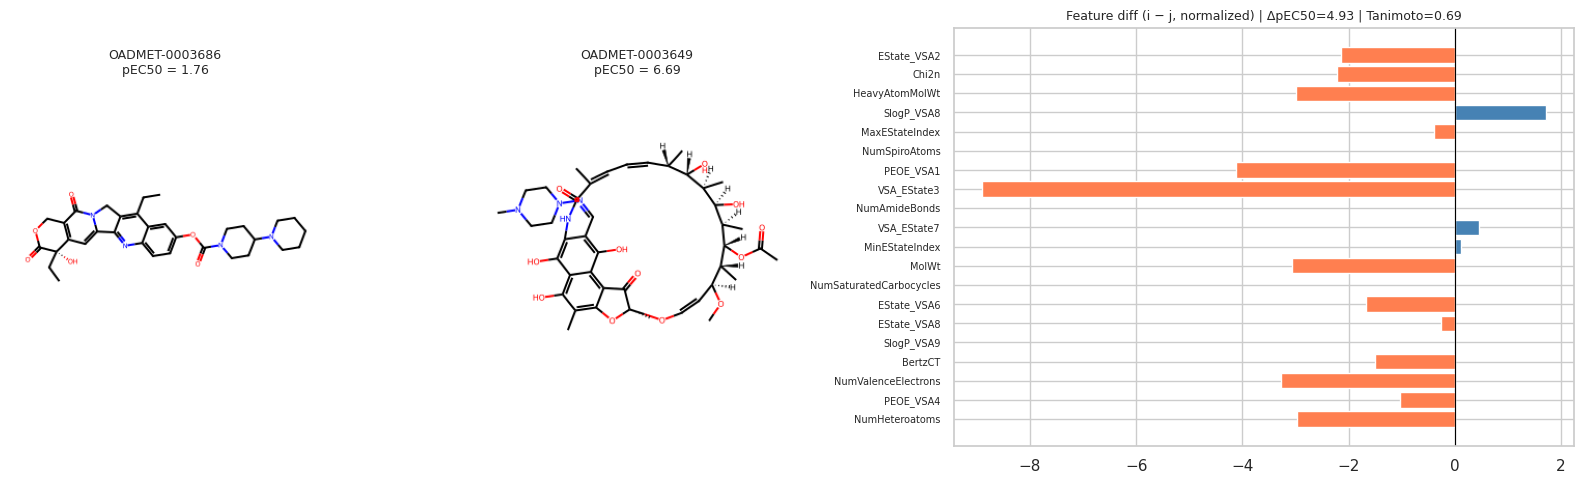

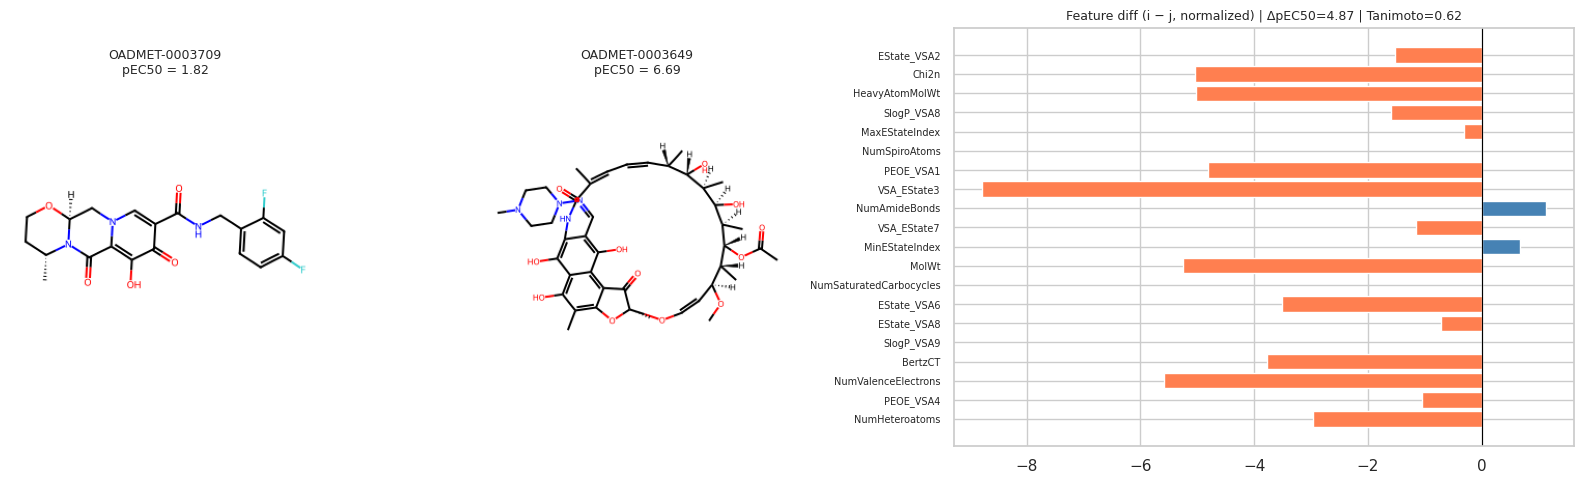

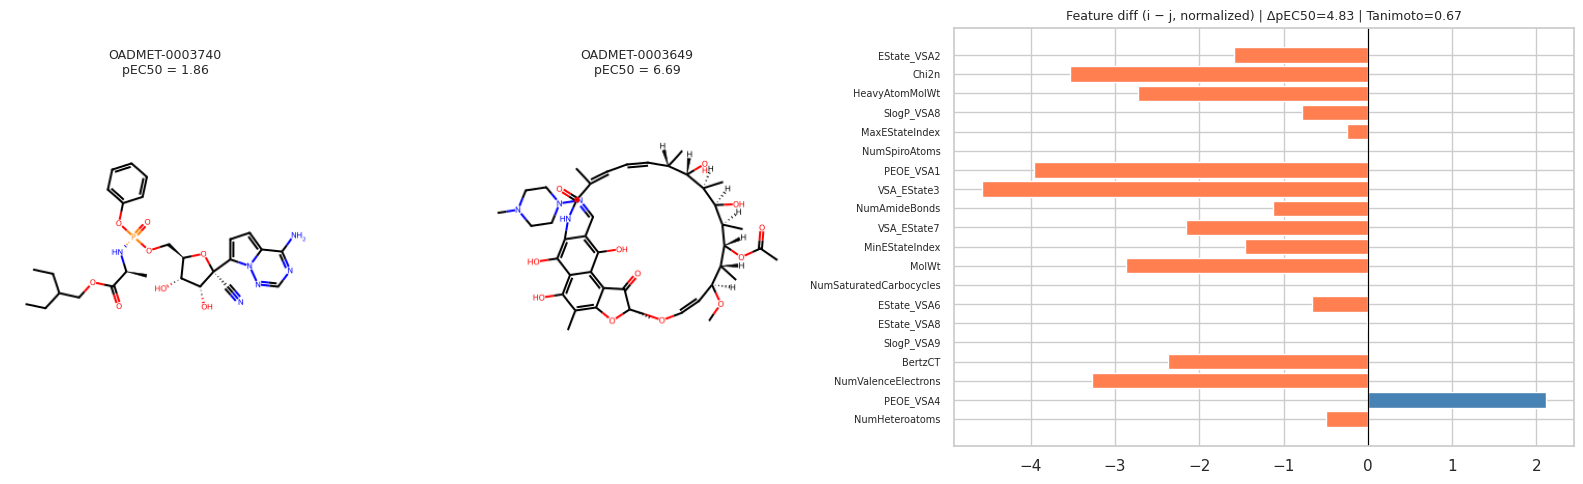

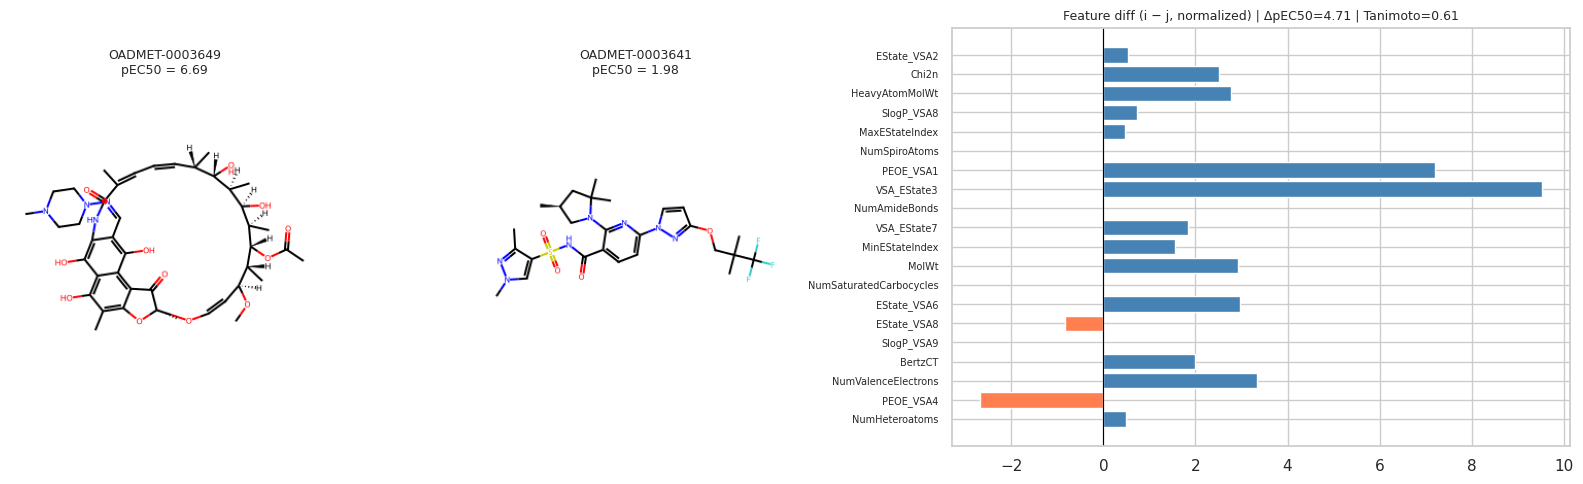

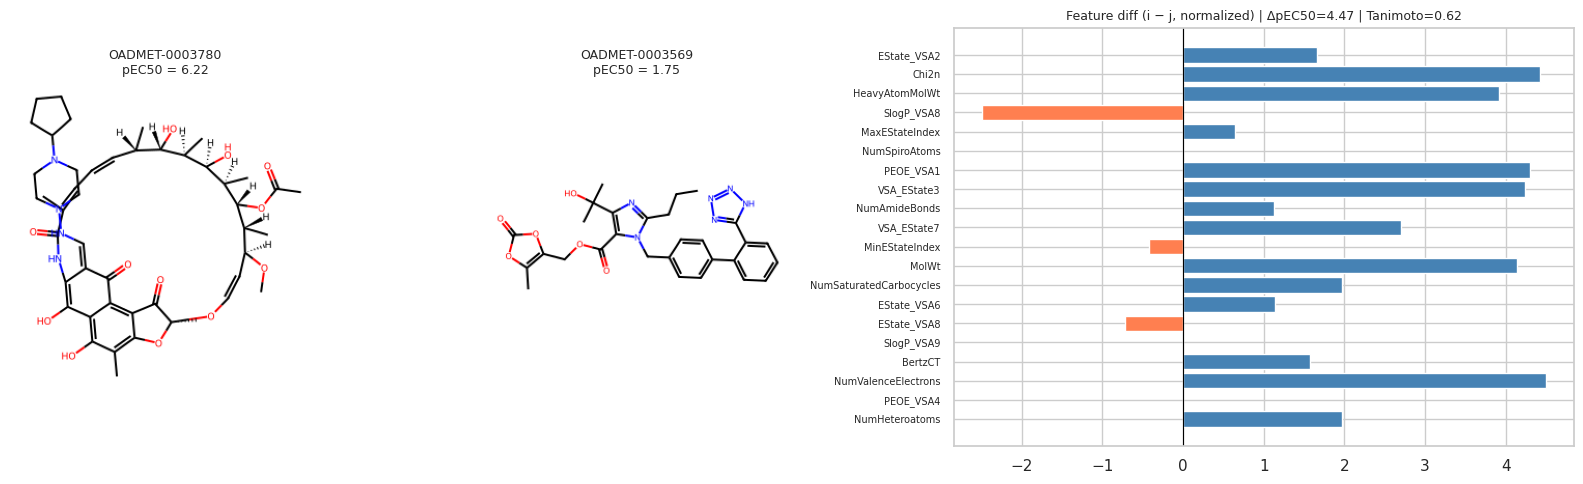

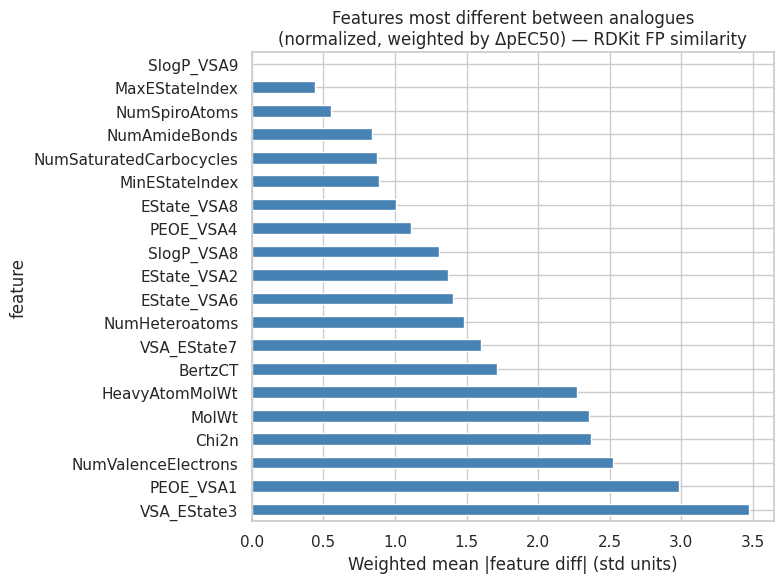

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, DataStructs
from rdkit.DataStructs import TanimotoSimilarity
from rdkit.Chem import AllChem, RDKFingerprint
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

TOP_FEATURES = [
    "NumHeteroatoms", "PEOE_VSA4", "NumValenceElectrons", "BertzCT",
    "SlogP_VSA9", "EState_VSA8", "EState_VSA6", "NumSaturatedCarbocycles",
    "MolWt", "MinEStateIndex", "VSA_EState7", "NumAmideBonds",
    "VSA_EState3", "PEOE_VSA1", "NumSpiroAtoms", "MaxEStateIndex",
    "SlogP_VSA8", "HeavyAtomMolWt", "Chi2n", "EState_VSA2"
]

def compute_top_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {f: np.nan for f in TOP_FEATURES}
    desc_dict = dict(Descriptors.CalcMolDescriptors(mol))
    return {f: desc_dict.get(f, np.nan) for f in TOP_FEATURES}

def get_rdkit_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return RDKFingerprint(mol)

# ── 1. Fit scaler on full training set ───────────────────────────────────────
print("Fitting scaler on training set...")
train_feat_matrix = pd.DataFrame(
    [compute_top_features(s) for s in train_pec50["SMILES"]],
    index=train_pec50["SMILES"]
).fillna(0)

scaler = StandardScaler()
scaler.fit(train_feat_matrix[TOP_FEATURES])

# ── 2. Find analogue pairs ────────────────────────────────────────────────────
print("Computing RDKit FPs for analogue search...")
train_pec50["_fp"] = train_pec50["SMILES"].apply(get_rdkit_fp)

def find_analogue_pairs(df, similarity_threshold=0.5, pec50_delta_threshold=1.5):
    fps = list(df["_fp"])
    smiles = list(df["SMILES"])
    pec50 = list(df["pEC50"])
    names = list(df["Molecule Name"]) if "Molecule Name" in df.columns else list(df.index)

    pairs = []
    for i in range(len(fps)):
        if fps[i] is None:
            continue
        for j in range(i + 1, len(fps)):
            if fps[j] is None:
                continue
            sim = TanimotoSimilarity(fps[i], fps[j])
            delta = abs(pec50[i] - pec50[j])
            if sim >= similarity_threshold and delta >= pec50_delta_threshold:
                pairs.append({
                    "idx_i": i, "idx_j": j,
                    "name_i": names[i], "name_j": names[j],
                    "smiles_i": smiles[i], "smiles_j": smiles[j],
                    "pec50_i": pec50[i], "pec50_j": pec50[j],
                    "delta_pec50": delta,
                    "tanimoto": sim,
                })
    return pd.DataFrame(pairs).sort_values("delta_pec50", ascending=False)

print("Finding analogue pairs (this may take a moment)...")
pairs_df = find_analogue_pairs(train_pec50, similarity_threshold=0.6, pec50_delta_threshold=1.5)
print(f"Found {len(pairs_df)} analogue pairs")

# ── 3. Precompute normalized features for all unique SMILES in pairs ──────────
print("Precomputing normalized features...")
unique_smiles = list(set(pairs_df["smiles_i"].tolist() + pairs_df["smiles_j"].tolist()))
raw_feat_matrix = pd.DataFrame(
    [compute_top_features(s) for s in unique_smiles],
    index=unique_smiles
).fillna(0)

scaled_values = scaler.transform(raw_feat_matrix[TOP_FEATURES])
scaled_feat_matrix = pd.DataFrame(scaled_values, index=unique_smiles, columns=TOP_FEATURES)

# ── 4. Plot pairs using normalized features ───────────────────────────────────
def plot_analogue_pair(row, ax_mol_i, ax_mol_j, ax_feat):
    mol_i = Chem.MolFromSmiles(row["smiles_i"])
    mol_j = Chem.MolFromSmiles(row["smiles_j"])
    img_i = Draw.MolToImage(mol_i, size=(300, 300))
    img_j = Draw.MolToImage(mol_j, size=(300, 300))
    ax_mol_i.imshow(img_i)
    ax_mol_i.set_title(f"{row['name_i']}\npEC50 = {row['pec50_i']:.2f}", fontsize=9)
    ax_mol_i.axis("off")
    ax_mol_j.imshow(img_j)
    ax_mol_j.set_title(f"{row['name_j']}\npEC50 = {row['pec50_j']:.2f}", fontsize=9)
    ax_mol_j.axis("off")

    fi = scaled_feat_matrix.loc[row["smiles_i"]]
    fj = scaled_feat_matrix.loc[row["smiles_j"]]
    feat_names, deltas = [], []
    for f in TOP_FEATURES:
        feat_names.append(f)
        deltas.append(fi[f] - fj[f])

    colors = ["steelblue" if d > 0 else "coral" for d in deltas]
    ax_feat.barh(feat_names, deltas, color=colors)
    ax_feat.axvline(0, color="black", linewidth=0.8)
    ax_feat.set_title(
        f"Feature diff (i − j, normalized) | ΔpEC50={row['delta_pec50']:.2f} | Tanimoto={row['tanimoto']:.2f}",
        fontsize=9
    )
    ax_feat.tick_params(axis="y", labelsize=7)

def plot_top_pairs(pairs_df, n=5):
    for _, row in pairs_df.head(n).iterrows():
        fig = plt.figure(figsize=(16, 5))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 2])
        ax_i = fig.add_subplot(gs[0])
        ax_j = fig.add_subplot(gs[1])
        ax_f = fig.add_subplot(gs[2])
        plot_analogue_pair(row, ax_i, ax_j, ax_f)
        plt.tight_layout()
        plt.show()

plot_top_pairs(pairs_df, n=5)

# ── 5. Aggregate normalized feature diffs across top 100 pairs ───────────────
records = []
for _, row in pairs_df.head(100).iterrows():
    fi = scaled_feat_matrix.loc[row["smiles_i"]]
    fj = scaled_feat_matrix.loc[row["smiles_j"]]
    for f in TOP_FEATURES:
        records.append({
            "feature": f,
            "abs_diff": abs(fi[f] - fj[f]),
            "delta_pec50": row["delta_pec50"]
        })

feat_diff_df = pd.DataFrame(records)
summary = (
    feat_diff_df.groupby("feature")
    .apply(lambda g: np.average(g["abs_diff"], weights=g["delta_pec50"]))
    .sort_values(ascending=False)
    .rename("weighted_mean_abs_diff_normalized")
)

summary.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Features most different between analogues\n(normalized, weighted by ΔpEC50) — RDKit FP similarity")
plt.xlabel("Weighted mean |feature diff| (std units)")
plt.tight_layout()
plt.show()

### Hypothesis: Does MolWt have a cutoff point where PEC50 increases?

             mean   std  count
mw_bin                        
(0, 228]     2.53  0.64    286
(228, 250]   3.14  0.74     59
(250, 270]   3.23  0.78     88
(270, 290]   3.87  1.03    146
(290, 310]   4.12  1.10    331
(310, 330]   4.48  0.94    593
(330, 350]   4.62  0.91    804
(350, 370]   4.52  1.00    626
(370, 396]   4.53  1.01    588
(396, 564]   4.72  0.99    591
(564, 2000]  3.85  1.58     28


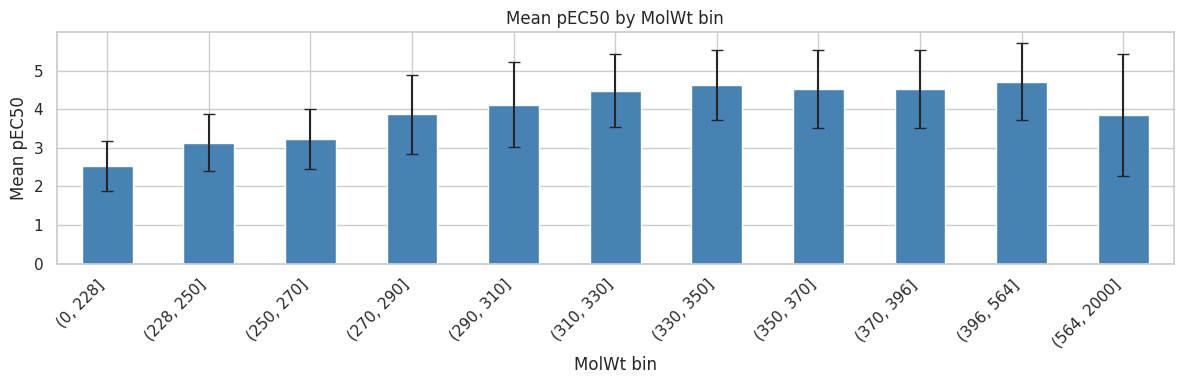

In [ ]:
from rdkit.Chem import Descriptors, Crippen

train_pec50["MolWt"] = train_pec50["SMILES"].apply(
    lambda s: Descriptors.MolWt(Chem.MolFromSmiles(s))
)
train_pec50["logP"] = train_pec50["SMILES"].apply(
    lambda s: Crippen.MolLogP(Chem.MolFromSmiles(s))
)

# Now bin and analyze
train_pec50["mw_bin"] = pd.cut(train_pec50["MolWt"],
    bins=[0, 228, 250, 270, 290, 310, 330, 350, 370, 396, 564, 2000])

print(train_pec50.groupby("mw_bin")["pEC50"].agg(["mean", "std", "count"]).round(2))

# Visualize it
fig, ax = plt.subplots(figsize=(12, 4))
summary = train_pec50.groupby("mw_bin")["pEC50"].agg(["mean", "std", "count"])
summary["mean"].plot(kind="bar", yerr=summary["std"], ax=ax, capsize=4, color="steelblue")
ax.set_title("Mean pEC50 by MolWt bin")
ax.set_xlabel("MolWt bin")
ax.set_ylabel("Mean pEC50")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

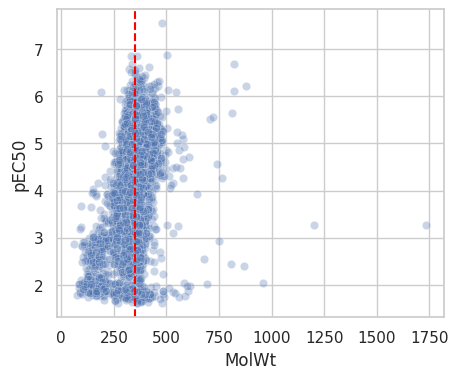

In [42]:
# Also plot MolWt vs pEC50 directly to see if there's a threshold
import seaborn as sns
sns.scatterplot(data=train_pec50, x="MolWt", y="pEC50", alpha=0.3)
plt.axvline(x=350, color="red", linestyle="--", label="possible threshold?")

Answer: Not really

# Modeling w new feats?